# Current Advanced Method implementation

Commit 580c427e

Test the output of the previous Leo version and the new CAM version.

In [1]:
from leo_utils import *

## Previous version of *Leo* 

Algorithm adapted from Holmstrom:

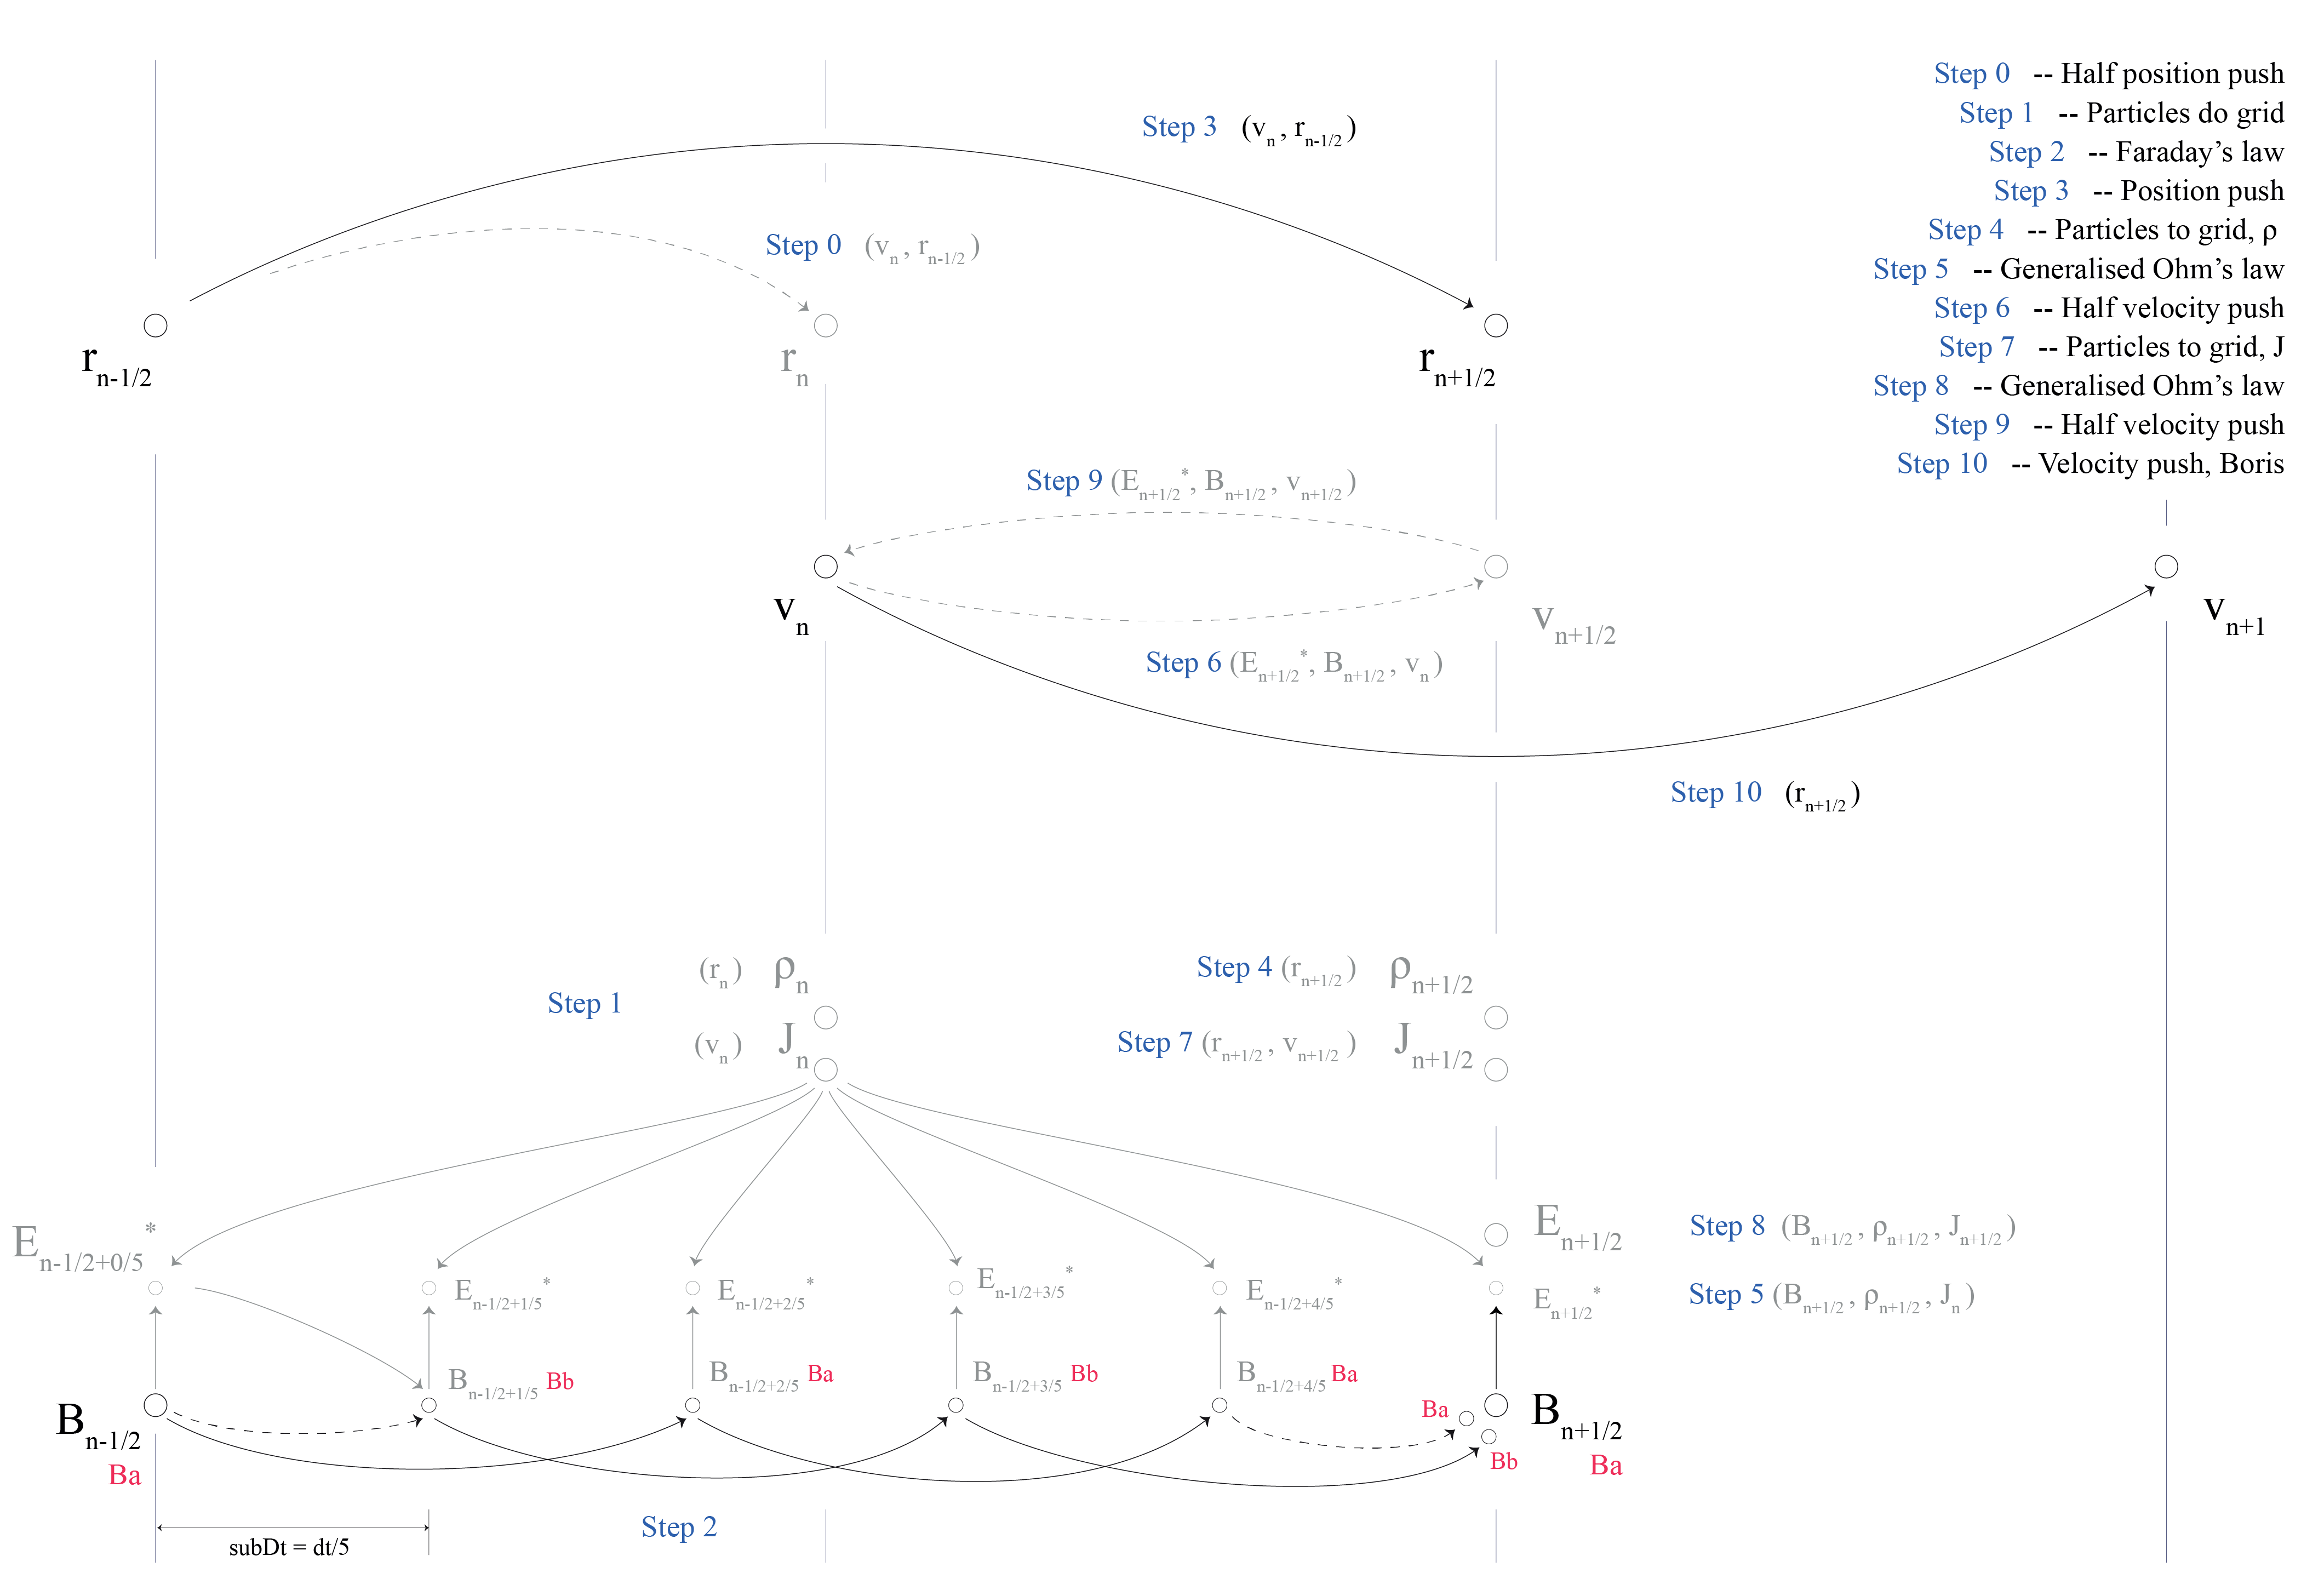

In [2]:
Image("../GdR/algo-01.png")

In [2]:
path = '../v_turbulent_plain'
i = 100
B = np.load(f'{path}/products/B_{i}.npy')
param_leo = read_leo_param(f'{path}/src', print_param=True)
grid, x_grid, y_grid, x_egdes, y_edges, dx = read_grid(f'{path}/products')
B0 = param_leo['B0']
bMag = norm(B/B0)


Run parameters:

q,                1.602e-19
m,                1.661e-27
m_e,              9.109e-31
mu0,              1.257e-06
eps0,             8.85e-12
k_B,              1.3806e-23
c,                299792458.0
xLen_cst,         128.0
yLen_cst,         128.0
nb_part_node_cst, 256.0
nb_it_max_cst,    100.0
nb_part_add_cst,  5000.0
nb_stack_cst,     128.0
seed_val_cst,     0.0
n0,               1500000.0
v0,               0.0
B0,               1e-09
fluctu_sqrt,      0.8
eta_res,          10.0
Ti_inf,           150000.0
Te_inf,           150000.0
dX,               2964073.0
nbSubCycles,      11.0
poly_ind,         1.0
counts_min,       1.0





## New CAM version

Following Bagdonat's thesis, the algorithm becomes the following, with only 4 passes in the particles, compared to n in the previous version.

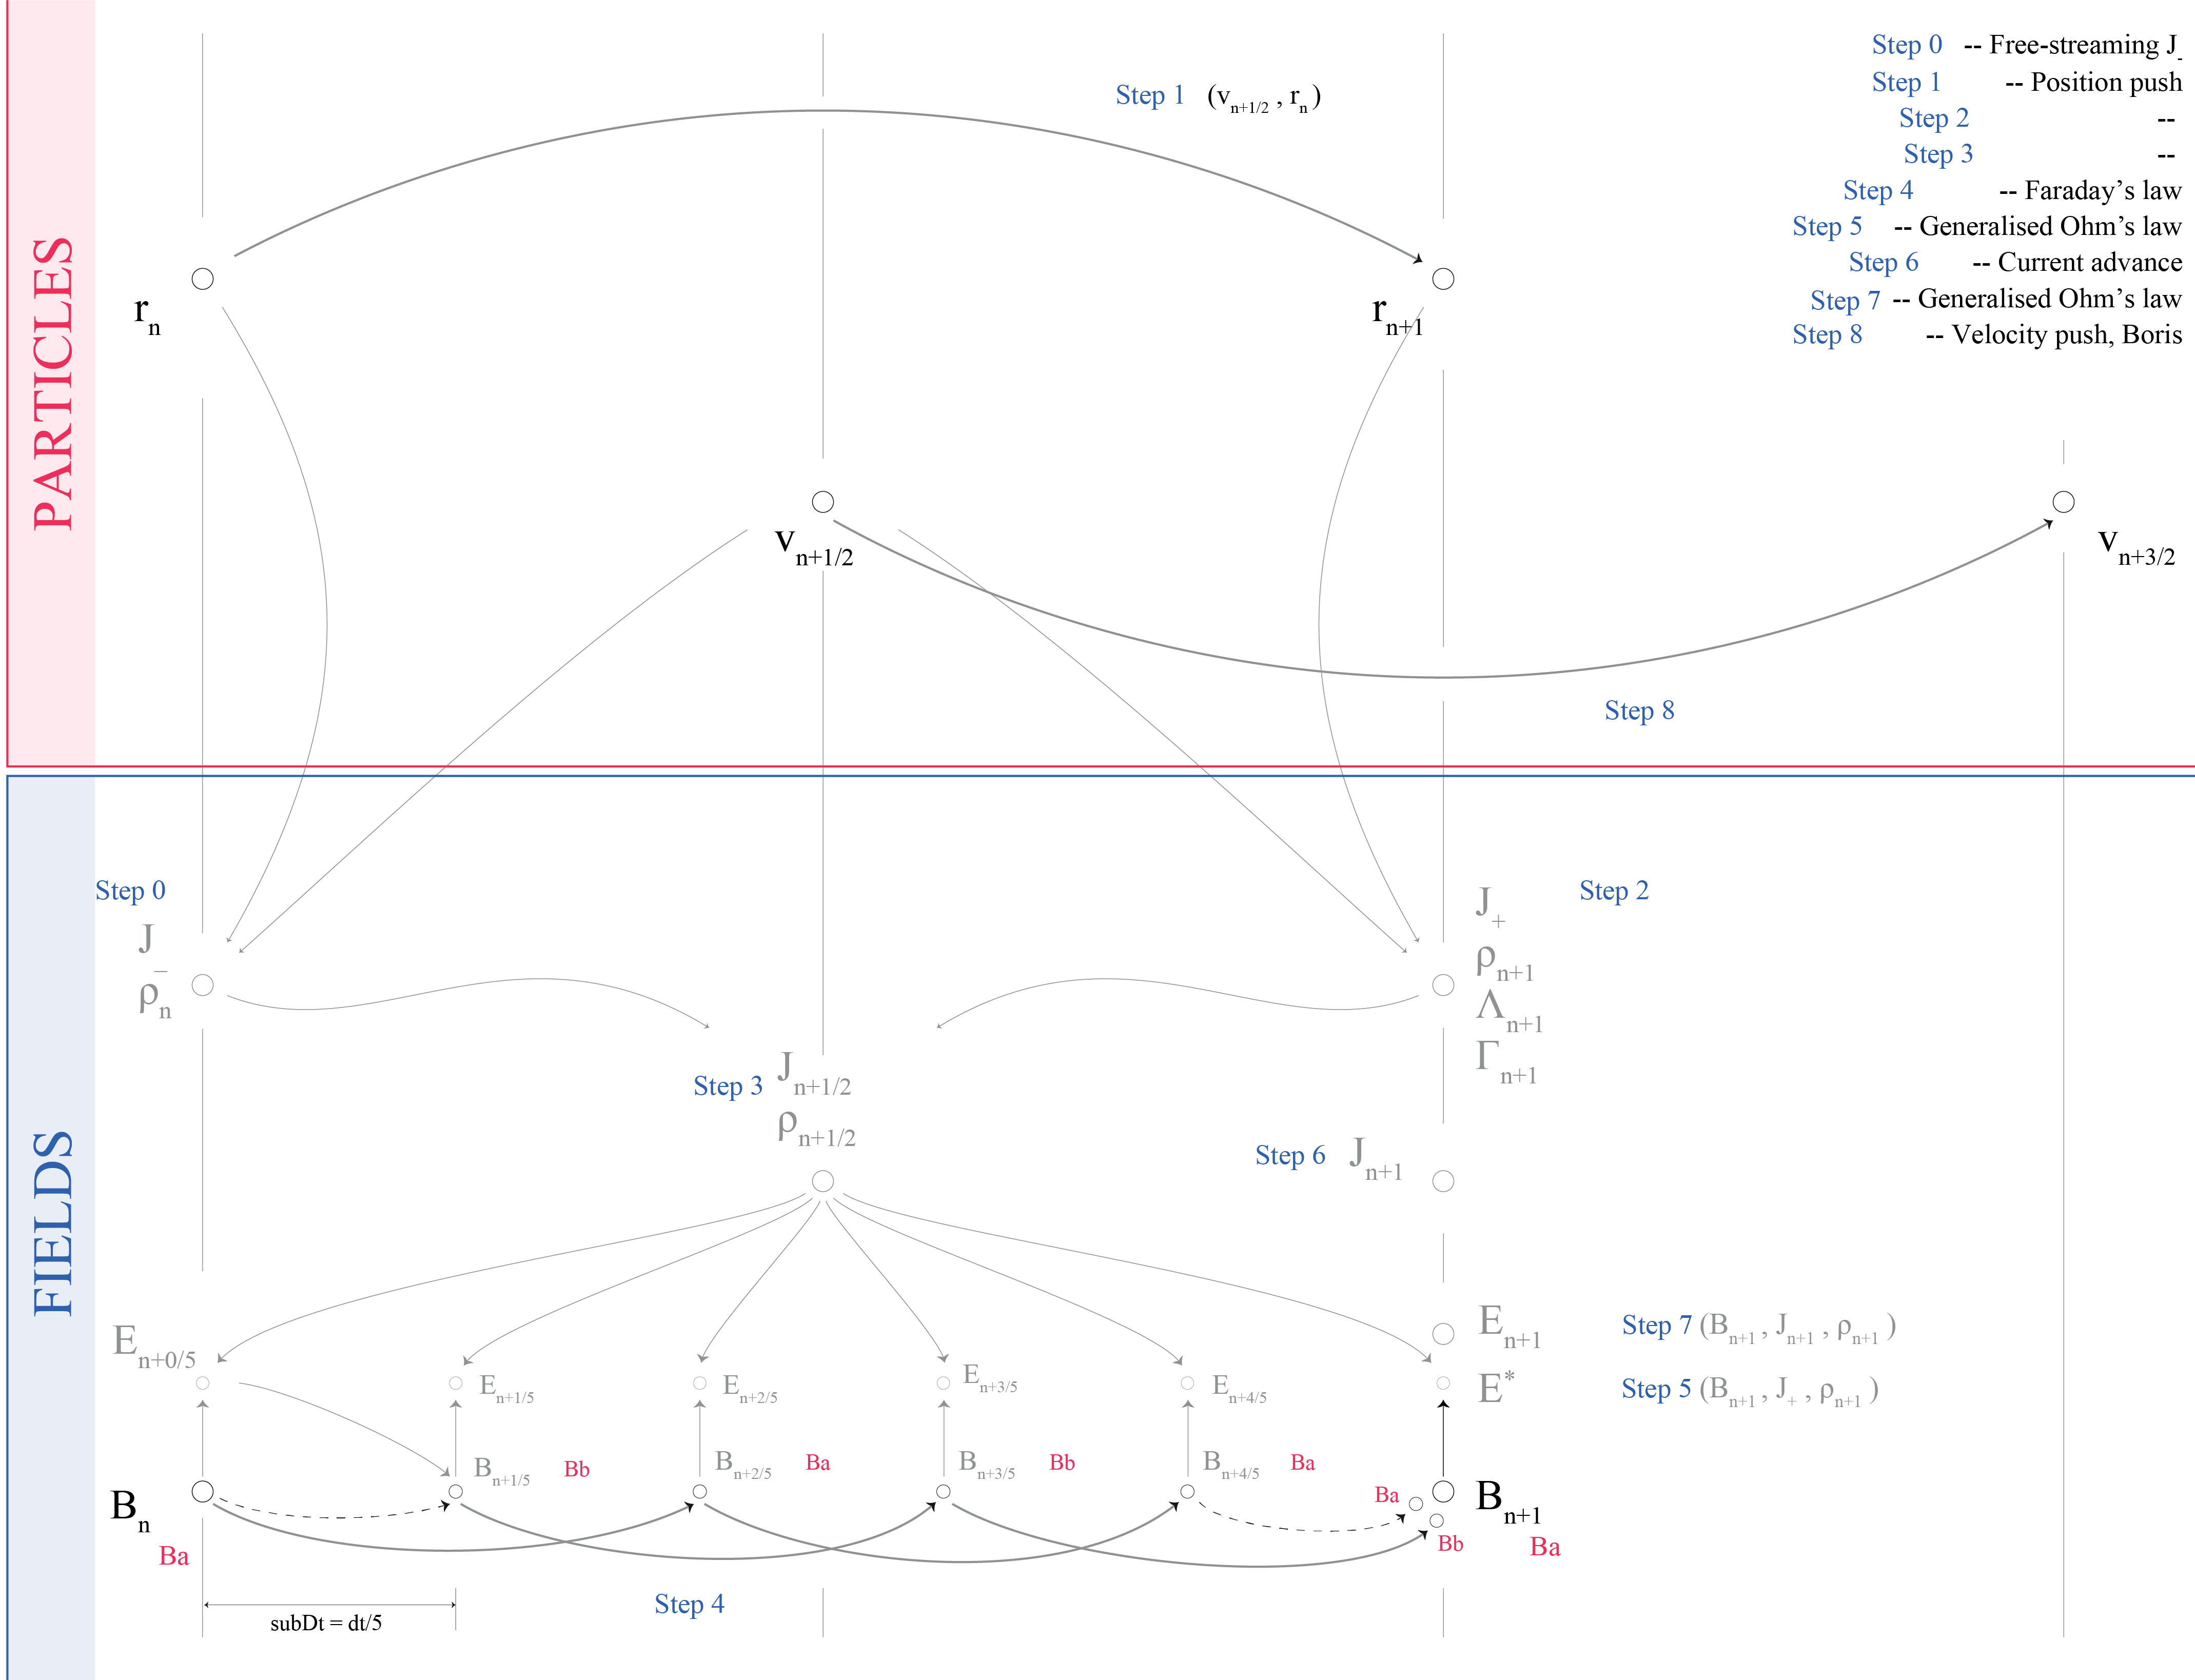

In [4]:
Image("../GdR/algo_cam-01.png")

In [3]:
path = '../v_turbulent_plain_cam'
i = 100
B = np.load(f'{path}/products/B_{i}.npy')
param_leo = read_leo_param(f'{path}/src', print_param=True)
B0 = param_leo['B0']
bMag_cam = norm(B/B0)
#bMag_cam = np.log10(norm(bMag_cam))


Run parameters:

q,                1.602e-19
m,                1.661e-27
m_e,              9.109e-31
mu0,              1.257e-06
eps0,             8.85e-12
k_B,              1.3806e-23
c,                299792458.0
xLen_cst,         128.0
yLen_cst,         128.0
nb_part_node_cst, 256.0
nb_it_max_cst,    100.0
nb_part_add_cst,  5000.0
nb_stack_cst,     128.0
seed_val_cst,     0.0
n0,               1500000.0
v0,               0.0
B0,               1e-09
fluctu_sqrt,      0.8
eta_res,          10.0
Ti_inf,           150000.0
Te_inf,           150000.0
dX,               2964073.0
nbSubCycles,      11.0
poly_ind,         1.0
counts_min,       1.0





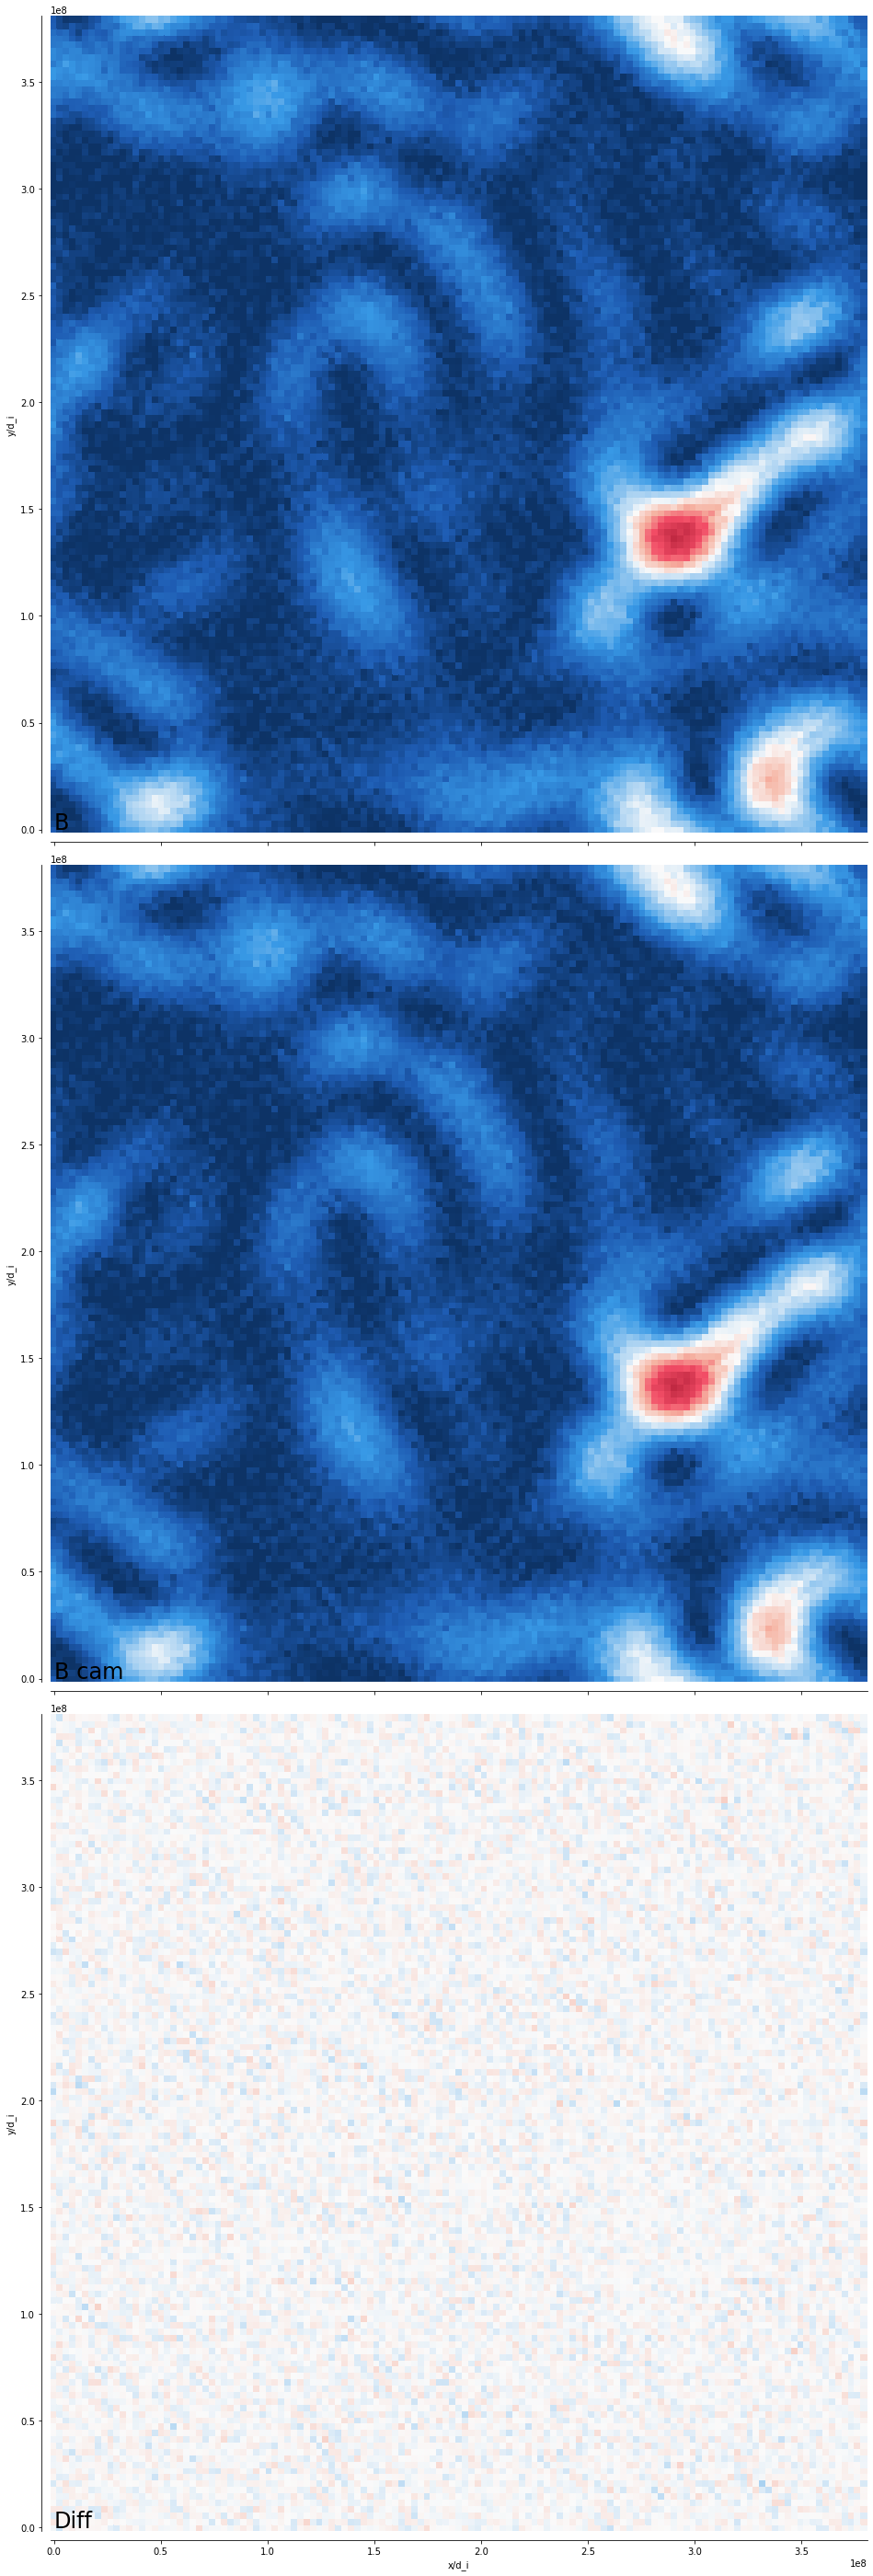

In [12]:
plot_2D_maps([np.log10(bMag), np.log10(bMag_cam), 100*(bMag-bMag_cam)/bMag], grid, vlim=[.15, .15, .1], cmap=oC.bwr_2, cmap_divergent=[False, False, True], labels=['B', 'B cam', 'Diff'])